<a href="https://colab.research.google.com/github/kduran-stack/climate_collection_kd/blob/main/ML_energy_demand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estimating Energy Demands with Machine Learning - Kyla Duran

With energy demand estimated to sky rocket due to data centers, I want to estimate the demand, the cost, and the environmental impact of the increase energy demand using Python machine learning tools.

I will be using a dataset I worked with previously using the language R. You can **find my previous project here**: https://github.com/kduran-stack/climate_collection_kd/blob/main/R_Energy_Project.ipynb


#Text portions of this notebook serve to demonstrate my knowledge and opinions on the subject


To learn more about the topic and help the model predict accurately **I will be reading several academic papers and videos.** I will reference the sources throughout the notebook and have a list of them at the bottom.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd

# About the Data (OWID - Energy Data)

Our World In Data (OWID) is a trusted aggregator of data. Using the world's energy authorities with a varity of metrics such as energy consumption, energy and electricity mix, and more. I have done extensive research on the different energy metrics in this dataset in order to effectively analysize it and come up with my research questions which I will be answering with R. **This dataset has over 3 million data points.**

A full description of the data can be found at: https://github.com/owid/energy-data/blob/master/owid-energy-codebook.csv

Citations:
 Hannah Ritchie, Pablo Rosado, and Max Roser (2023) - “Energy” Published online at OurWorldinData.org. Retrieved from: 'https://ourworldindata.org/energy' [Online Resource]

In [3]:

url = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"

df = pd.read_csv(url)
#df.head()





# Weak Link Theory - Why I believe innovation is the only solution to keeping America competitive in AI

America's energy grid has remained stagnant for the past two decades, while China's power capabilities have grown seven times according to Bloomberg's video report, "How the Electrical Grid is Being Rebuilt for AI". This highlights an inevitable "weak link" in America's ability to keep up with China in this AI race.

Anything is as strong as its weakest link. Professor of Economics at Stanford University, Chad Jones, has applied this idea to AI's economic impact on our daily lives, but I would also apply it to America's ability to launch AI on a massive scale.

Professor Jones used the example of how a 10 dollar O-ring could destroy a $3.2 billion dollar machine, similarly a power grid can take down trillions dollars worth of investment in AI.

I will be exploring the different nuances of this problem in this section.

Sources:

Jones, C. (2026, May 21). A.I. and Our Economic Future [Video]. YouTube. https://youtu.be/xBpGn3BDcOY

Bloomberg Originals. (2026). How the Electrical Grid Is Being Rebuilt for AI | Bloomberg Primer [Video]. YouTube. https://youtu.be/8KOYyfZbPzo

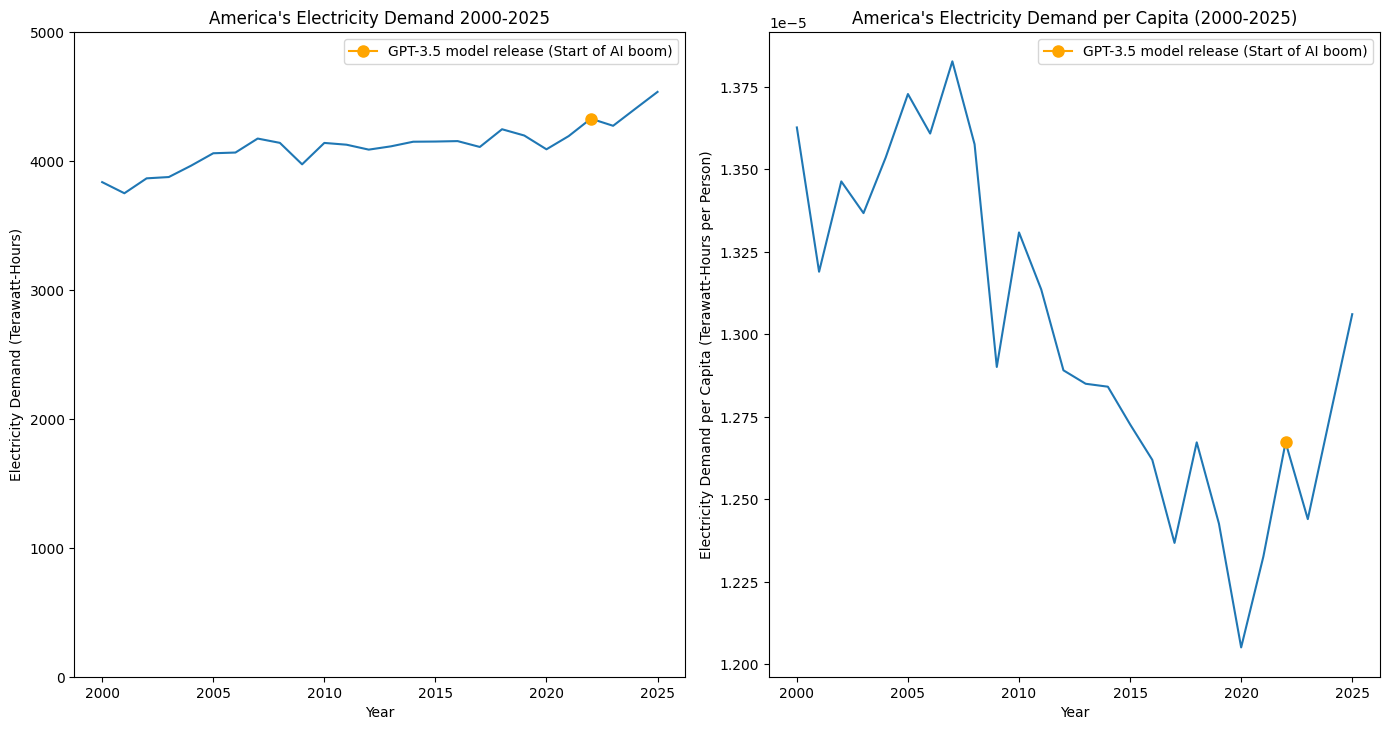

In [31]:
#rows
row_mask = (df["iso_code"] == "USA") & (df["year"].between(1985, 2025)) #Looking at the headers: column header = iso, stop at column value USA
#columns
columns = ["iso_code", "year", "electricity_demand"] #columns that we mentioned previously, of which we only wanted particular parts (which is why we did the row mask) + electricity demand
america_unmasked = df.loc[row_mask, columns]




# Create a mask column directly in pandas, do not used np.ma.masked_where because this will change it into a numpy dataframe
america_unmasked = df.loc[row_mask, columns]

# Drop rows where electricity_demand is NAN (only doing electricity_demand)
america = america_unmasked.dropna(subset=["electricity_demand"])

#america.head() #starts at 2000

#america_unmasked.head() #starts at 1985




# Create a figure with a clean layout size
plt.figure(figsize=(14, 14))  #width,height


# Changed to spanning 4 rows and 4 columns so they fill up the 8x8 space nicely - AI fix
ax1 = plt.subplot2grid((8,8), (0,0), rowspan=4, colspan=4) # America's electricity demand
ax2 = plt.subplot2grid((8,8), (0,4), rowspan=4, colspan=4) # America's Electricity demand per capita

# Plot 1: Absolute Demand
ax1.plot(america["year"], america["electricity_demand"])
ax1.set_yticks(np.arange(0, 5001, 1000))
ax1.set(
    ylim=(0, 5000),
    xlabel="Year",
    ylabel="Electricity Demand (Terawatt-Hours)",
    title="America's Electricity Demand 2000-2025"
)

# Data Processing for Plot 2
rows = (df["iso_code"] == "USA") & (df["year"]).between(2000, 2025)
col = ["iso_code", "year", "electricity_demand_per_capita"]

america_per_unmasked = df.loc[rows, col]
america_per = america_per_unmasked.dropna(subset=["electricity_demand_per_capita"]).copy()

# Conversion
america_per["electricity_demand_per_capita"] = america_per["electricity_demand_per_capita"] / 1_000_000_000

#dot mask first graph:

a1_2022 = america[america["year"] == 2022]
a1_demand_2022 = a1_2022["electricity_demand"]
ax1.plot(2022, a1_demand_2022, marker="o", color="orange", markersize=8, label="GPT-3.5 model release (Start of AI boom)")
#average line before chatgpt (will need to put statistics before this and move data before this also)
#ax1.axhline(y=avg_2000_2022, color="pink", linestyle="--", label="Average Terawatt Hours before Chatgpt")

ax1.legend()



# Mask for 2022 dot
row_2022 = america_per[america_per["year"] == 2022]
demand_2022 = row_2022["electricity_demand_per_capita"]

ax2.plot(america_per["year"], america_per["electricity_demand_per_capita"])
ax2.set_xlabel("Year")
ax2.set_ylabel("Electricity Demand per Capita (Terawatt-Hours per Person)")
ax2.set_title("America's Electricity Demand per Capita (2000-2025)")

#trying to make both graphs the same y scale
# ax2.set(
#     ylim=(0, 5000),
#     xlabel="Year",
#     ylabel="Electricity Demand per Capita (Terawatt-Hours per Person)",
#     title="America's Electricity Demand per Capita (2000-2025)"
# )

# Dot
ax2.plot(2022, demand_2022, marker="o", color="orange", markersize=8, label="GPT-3.5 model release (Start of AI boom)")

ax2.legend()

plt.tight_layout() # Automatically adjust spacing so labels don't overlap

#plt.show()


In [27]:
#Statistics:
years= 25
min_val=america["electricity_demand"].min()
max_val= america["electricity_demand"].max()
abs_growth = (max-min)
total_pct_growth = (abs_growth / min_val) * 100
avg_annual_twh = abs_growth / years
cagr = ((max_val / min_val) ** (1 / years) - 1) * 100

#year average up until: 2022
filtered_demand = america[(america["year"] >= 2000) & (america["year"] <= 2022)]
avg_2000_2022 = filtered_demand["electricity_demand"].mean()


avg_2000_2022 = filtered_demand["electricity_demand"].dropna().mean()
print(f"Average Demand (2000-2022): {avg_2000_2022:.2f} TWh")


#rounded metrics
print(f"Absolute Growth:         {abs_growth:.2f} TWh")
print(f"Total Percentage Growth: {total_pct_growth:.2f}%")
print(f"Average Annual Increase: {avg_annual_twh:.2f} TWh/year")
print(f"CAGR (Annualized Pace):  {cagr:.2f}%")

Average Demand (2000-2022): 4077.71 TWh
Absolute Growth:         786.21 TWh
Total Percentage Growth: 20.97%
Average Annual Increase: 31.45 TWh/year
CAGR (Annualized Pace):  0.76%


The Bloomberg video, provides context on how the energy grid started and how it has progressed since then. At the beginning of the 20th century, electricity started to become a major energy source. By the 1930s, 70% of American homes had electricity. A 1970s oil crisis that made increased the price of energy, started a push for more energy efficiency. Coupled with the fact America moved away from manufacturing to more office work, which required less energy, a common trend for richer nations. By the 21st century, energy demand began to level off.

https://www.electricchoice.com/blog/50-surprising-facts-on-energy-consumption/

To do:

America's energy output compared to Chinas, put these two on a subplot

In [7]:
# #sub2grid example



# fig =plt.figure(figsize=[9,12])

# #defining axis
# ax1 = plt.subplot2grid((8,2),(0,0),rowspan=2,colspan=2) #catches per year
# ax2 = plt.subplot2grid((8,2),(2,0), rowspan=2,colspan=2)
# ax3 = plt.subplot2grid((8,2),(4,0), rowspan=2, colspan=2)
# ax4= plt.subplot2grid((8,2),(6,0), rowspan=2, colspan=2)

# ax1.xaxis.set_ticklabels([])
# ax2.xaxis.set_ticklabels([])
# ax3.xaxis.set_ticklabels([])


# ax1.set_title('Historical Maine Lobster Landings: (1880-2025)')
# ax1.set_ylabel('Catches Per Year (Lbs Millions)')
# ax2.set_ylabel('Adjusted Value ($ Millions)')
# ax3.set_ylabel('Number of Traps (Millions)')
# ax4.set_ylabel('Water Temperature (C)')


# ax1.plot(year,pounds_millions)
# ax2.plot(year,adjusted_value_millions)
# ax3.plot(year, traps_millions)
# ax4.plot(year, water_temp_cel)